In [ ]:
# script que implementa FinaleToolkit para análisis fragmentómico
# https://github.com/epifluidlab/FinaleToolkit
# autora: suarezhs@uoc.edu

El pipeline se ha instalado previamente en conda. El environment está disponible en el repositorio https://github.com/sara-suarez93/bcltofragmentomics (environment.yaml).

In [ ]:
#!conda install -c bioconda -c conda-forge finaletoolkit

# Importar datos

In [8]:
# working directory to root folder
import glob
import os
#os.chdir('/mnt/scratch_dir/suarezhs/tfm/bcltofragmentomics/')
os.chdir('/Users/sarasuarez/Desktop/bcltofragmentomics')

# resultados
results_frag = 'results/01_fragment_lengths'
results_endmot = 'results/02_endmotifs'

# crearlos
os.makedirs(results_frag, exist_ok=True)
os.makedirs(results_endmot, exist_ok=True)

# Información del paquete

In [556]:
# que hay en el paquete porque no encuento documentacion que no sea
# para el command line
import finaletoolkit as ftk
import pkgutil
import importlib

for m in pkgutil.iter_modules(ftk.__path__):
    print(m.name)

submodules = ["cli", "frag", "genome", "utils", "version"]

for sm in submodules:
    print("\n### Submodule:", sm)
    mod = importlib.import_module(f"finaletoolkit.{sm}")
    print(dir(mod))

cli
frag
genome
utils
version

### Submodule: cli
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']

### Submodule: frag
['BreakpointMotifFreqs', 'BreakpointMotifsIntervals', 'EndMotifFreqs', 'EndMotifsIntervals', 'FPROFILE_PATH', 'Iterable', 'Iterator', 'MIN_QUALITY', 'NDArray', 'Path', 'Pool', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_adjust_wps', '_breakpoint_motifs', '_cleavage_profile', '_coverage', '_delfi', '_delfi_gc_correct', '_delfi_merge_bins', '_end_motifs', '_frag_length', '_multi_wps', '_wps', 'adjust_wps', 'annotations', 'breakpoint_motifs', 'cleavage_profile', 'coverage', 'delfi', 'delfi_gc_correct', 'delfi_merge_bins', 'end_motifs', 'files', 'frag_generator', 'frag_length', 'frag_length_bins', 'frag_length_intervals', 'gzip', 'interval_breakpoint_motifs', 'interval_end_motifs', 'multi_wps', 'np', 'pkg_data', 'py2bit', 'regio

In [557]:
import finaletoolkit.frag as frag

# uso funcion para longitud de motivos
help(frag.frag_length_bins)

Help on function frag_length_bins in module finaletoolkit.frag._frag_length:

frag_length_bins(input_file: 'FragFile', contig: 'str | None' = None, start: 'int | None' = None, stop: 'int | None' = None, min_length: 'int | None' = 0, max_length: 'int | None' = None, bin_size: 'int' = 1, output_file: 'str | None' = None, intersect_policy: 'str' = 'midpoint', quality_threshold: 'int' = 30, summary_stats: 'bool' = False, short_fraction: 'int | None' = None, histogram_path: 'str | None' = None, verbose: 'Union[bool, int]' = False) -> 'tuple[np.ndarray, np.ndarray]'
    Takes input_file, computes frag lengths of fragments and returns
    two arrays containing bins and counts by size. Optionally prints
    data to output as a tab delimited table or histogram.
    
    Parameters
    ----------
    input_file : str, AlignmentFile, or TabixFile
        BAM, CRAM, or tabix-indexed containing paired-end fragment reads or
        its path. pysam wrappers must be opened in read mode.
    contig : s

In [43]:
# funcion motivos de corte
help(frag.end_motifs)

Help on function end_motifs in module finaletoolkit.frag._end_motifs:

end_motifs(input_file: 'str', refseq_file: 'str | Path', k: 'int' = 4, min_length: 'int | None' = 50, max_length: 'int | None' = None, both_strands: 'bool' = True, negative_strand: 'bool' = False, output_file: 'None | str' = None, quality_threshold: 'int' = 30, workers: 'int' = 1, verbose: 'bool | int' = False, fraction_low: 'int | None' = None, fraction_high: 'int | None' = None) -> 'EndMotifFreqs'
    Function that reads fragments from a BAM, CRAM, or tabix indexed
    file and returns the 5' k-mer (default is 4-mer) end motif
    frequencies as a dictionary. Optionally writes data to a tsv. This
    function reproduces the methodology of Zhou et al (2023).

    Parameters
    ----------
    input_file : str
        BAM, CRAM, or Frag.gz file with paired-end reads.
    refseq_file : str or Path
        2bit file with sequence of reference genome input_file is
        aligned to.
    k : int, optional
        Lengt

# Implementación FinaleToolKit

## QC: filtrado de lecturas con alta calidad de secuenciación

Aplica los siguientes filtros de acuerdo con la publicación de FinaleToolKit: https://pmc.ncbi.nlm.nih.gov/articles/PMC12597888/

*Only high-quality reads were considered in the analysis (high quality: uniquely mapped, no PCR duplicates, both ends are mapped
with mapping qualities more than 30, and properly paired).*

In [ ]:
# script 00_qc.py
# bsub -o logs_hpc/out_qc.txt -e logs_hpc/err_qc.txt -q bio -n 1 -W 2800 -M 64000 -hl -R 'rusage[mem=64000]' python scripts/00_qc_after.py

## Longitud de fragmentos

* Genera .tsv a partir de .markdup.bam (antes de QC) y filtered.bam (despues de QC) para histogramas
* En HPC por velocidad: script *01_fragment_lengths.py*

In [ ]:
# script 01_fragment_lengths.py
# bsub -o logs_hpc/out_fraglength.txt -e logs_hpc/err_fraglength.txt -q bio -n 1 -W 1400 -M 64000 -hl -R 'rusage[mem=64000]' python scripts/01_fragment_lengths.py

**TSV-frag_length_bins():**

In [4]:
import pandas as pd
pd.read_csv(os.path.join(results_frag, "L-25000010_S5.markdup.tsv"), 
                         index_col=None, 
                         sep='\t').head()

,min,max,count
0,78,78,2426
1,79,79,3117
2,80,80,3601
3,81,81,6597
4,82,82,5500


### Muestras cáncer de colon

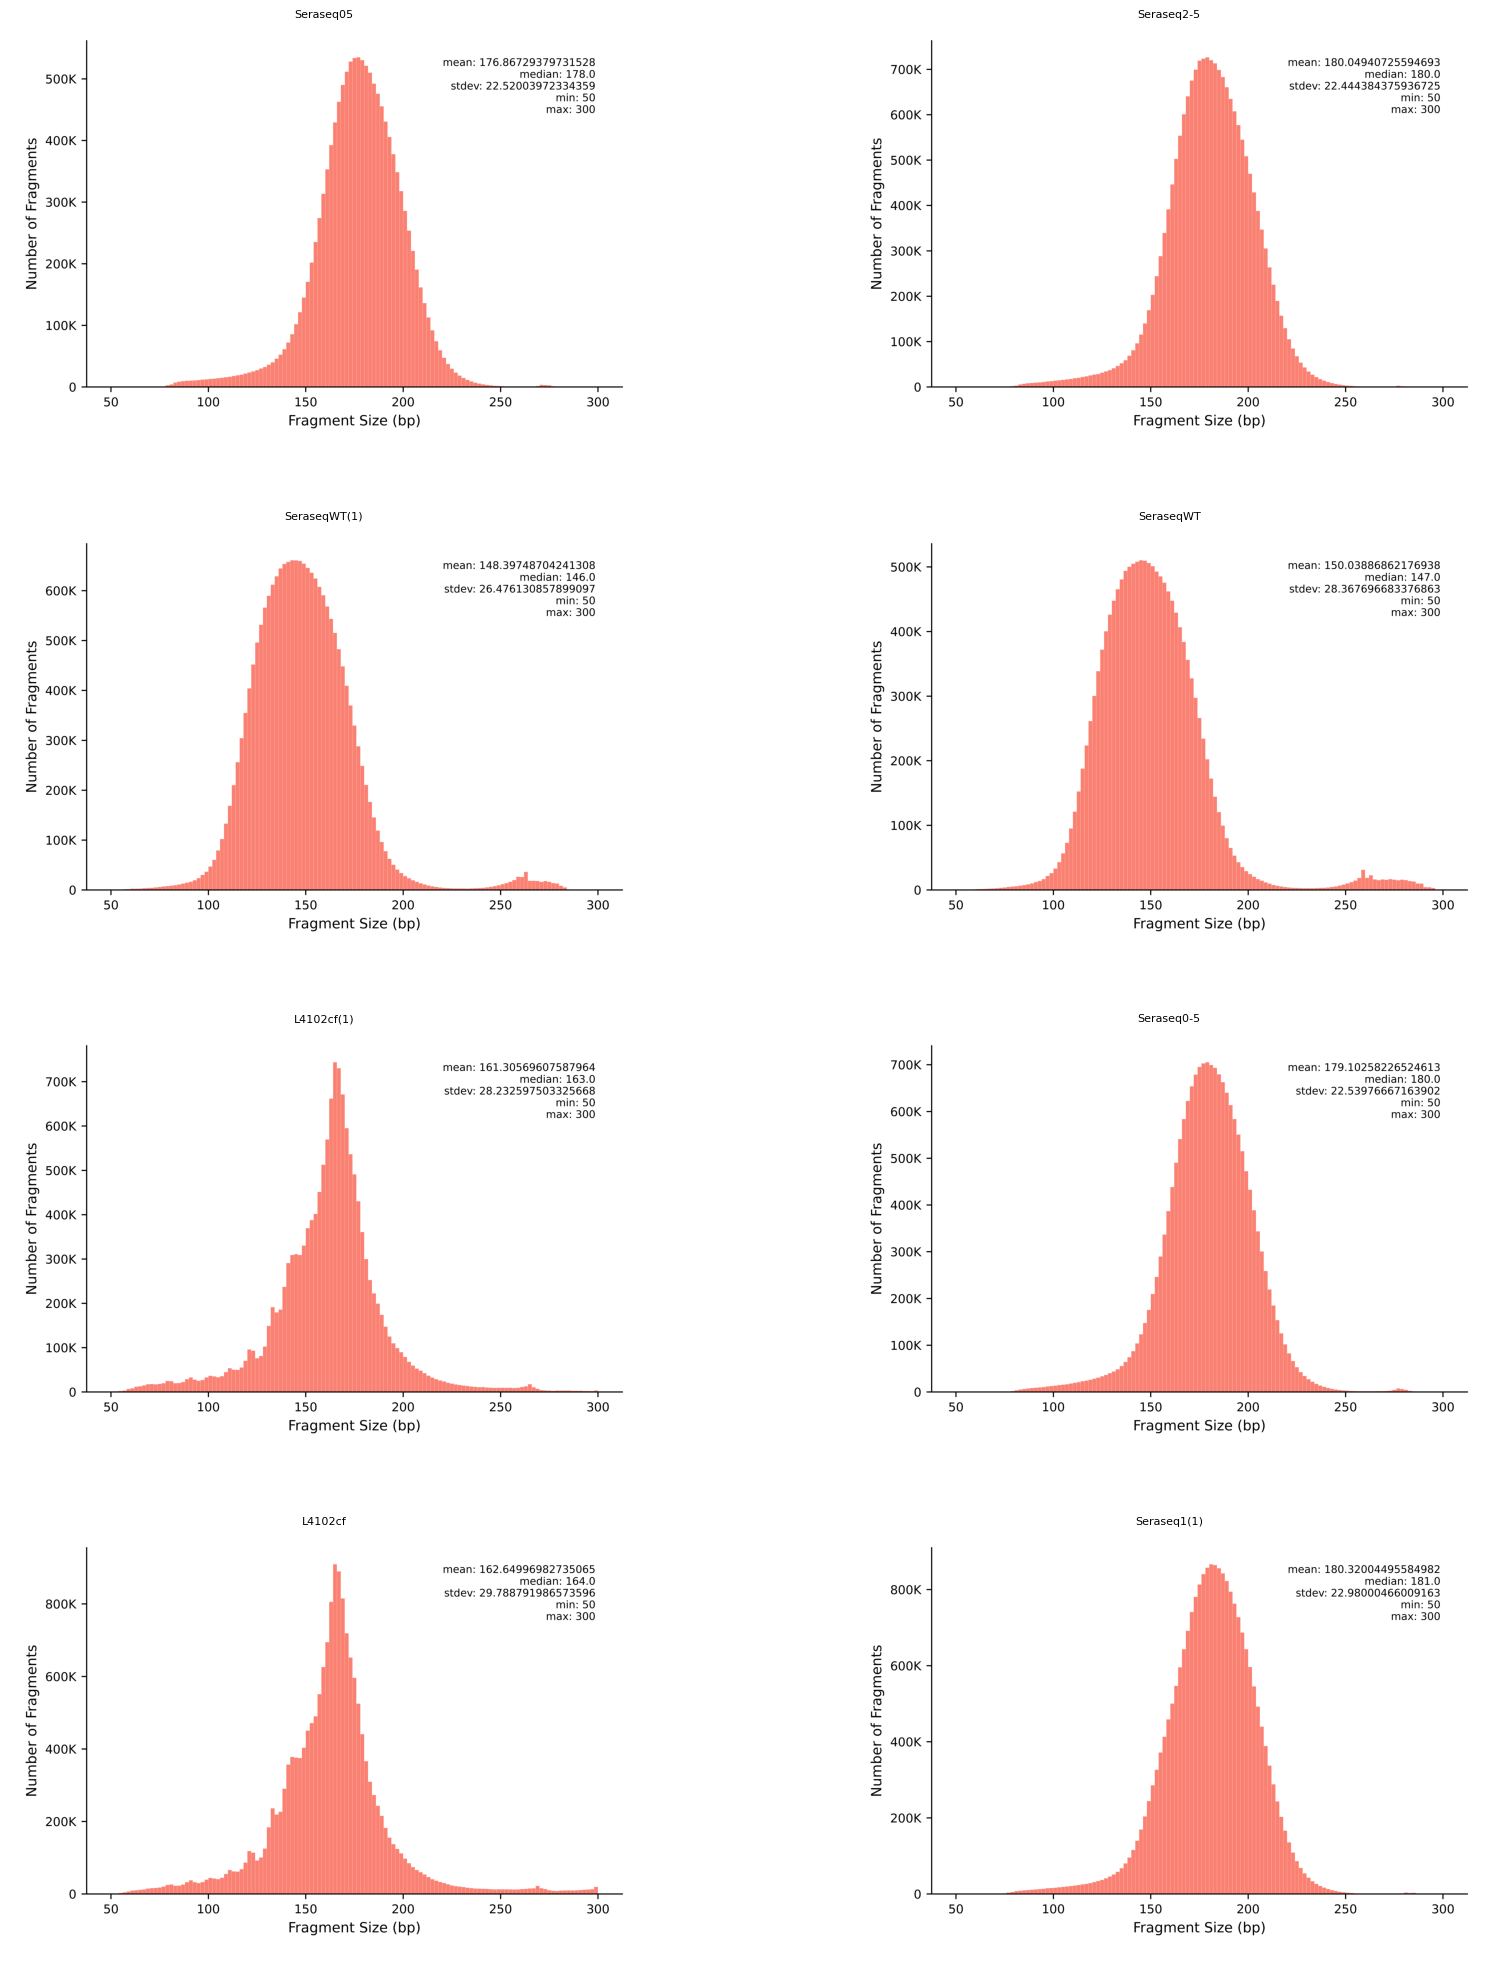

In [558]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pngfiles_ivan = glob.glob('data_colon/*.png')

# defino panel 
fig, axes = plt.subplots(4, 2, figsize=(20, 25))

# Flatten axes array for easy iteration
axes = axes.flatten()

# iteramos en axis e imagenes
for ax, img_path in zip(axes, pngfiles_ivan):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")  # no ticks or frames

    # saco el nombre
    fname = os.path.basename(img_path)

    # cogo lo de antes de .bam
    title = fname.split(".bam")[0]

    # Set the subplot title
    ax.set_title(title, fontsize=8)

### Ejemplo muestras NSCLC pre-QC

Archivos .markdup.png

In [7]:
list_pool527 = ['L-25000063_S1', 'L-25000080_S8', 'L-25000065_S2', 'L-25000071_S4', 'L-25000075_S6', 'L-25000076_S5', 'L-25000069_S3', 'L-25000066_S7']
list_pool527

['L-25000063_S1',
 'L-25000080_S8',
 'L-25000065_S2',
 'L-25000071_S4',
 'L-25000075_S6',
 'L-25000076_S5',
 'L-25000069_S3',
 'L-25000066_S7']

['results/01_fragment_lengths/L-25000065_S2.markdup.png', 'results/01_fragment_lengths/L-25000080_S8.markdup.png', 'results/01_fragment_lengths/L-25000071_S4.markdup.png', 'results/01_fragment_lengths/L-25000066_S7.markdup.png', 'results/01_fragment_lengths/L-25000063_S1.markdup.png', 'results/01_fragment_lengths/L-25000069_S3.markdup.png', 'results/01_fragment_lengths/L-25000075_S6.markdup.png', 'results/01_fragment_lengths/L-25000076_S5.markdup.png']


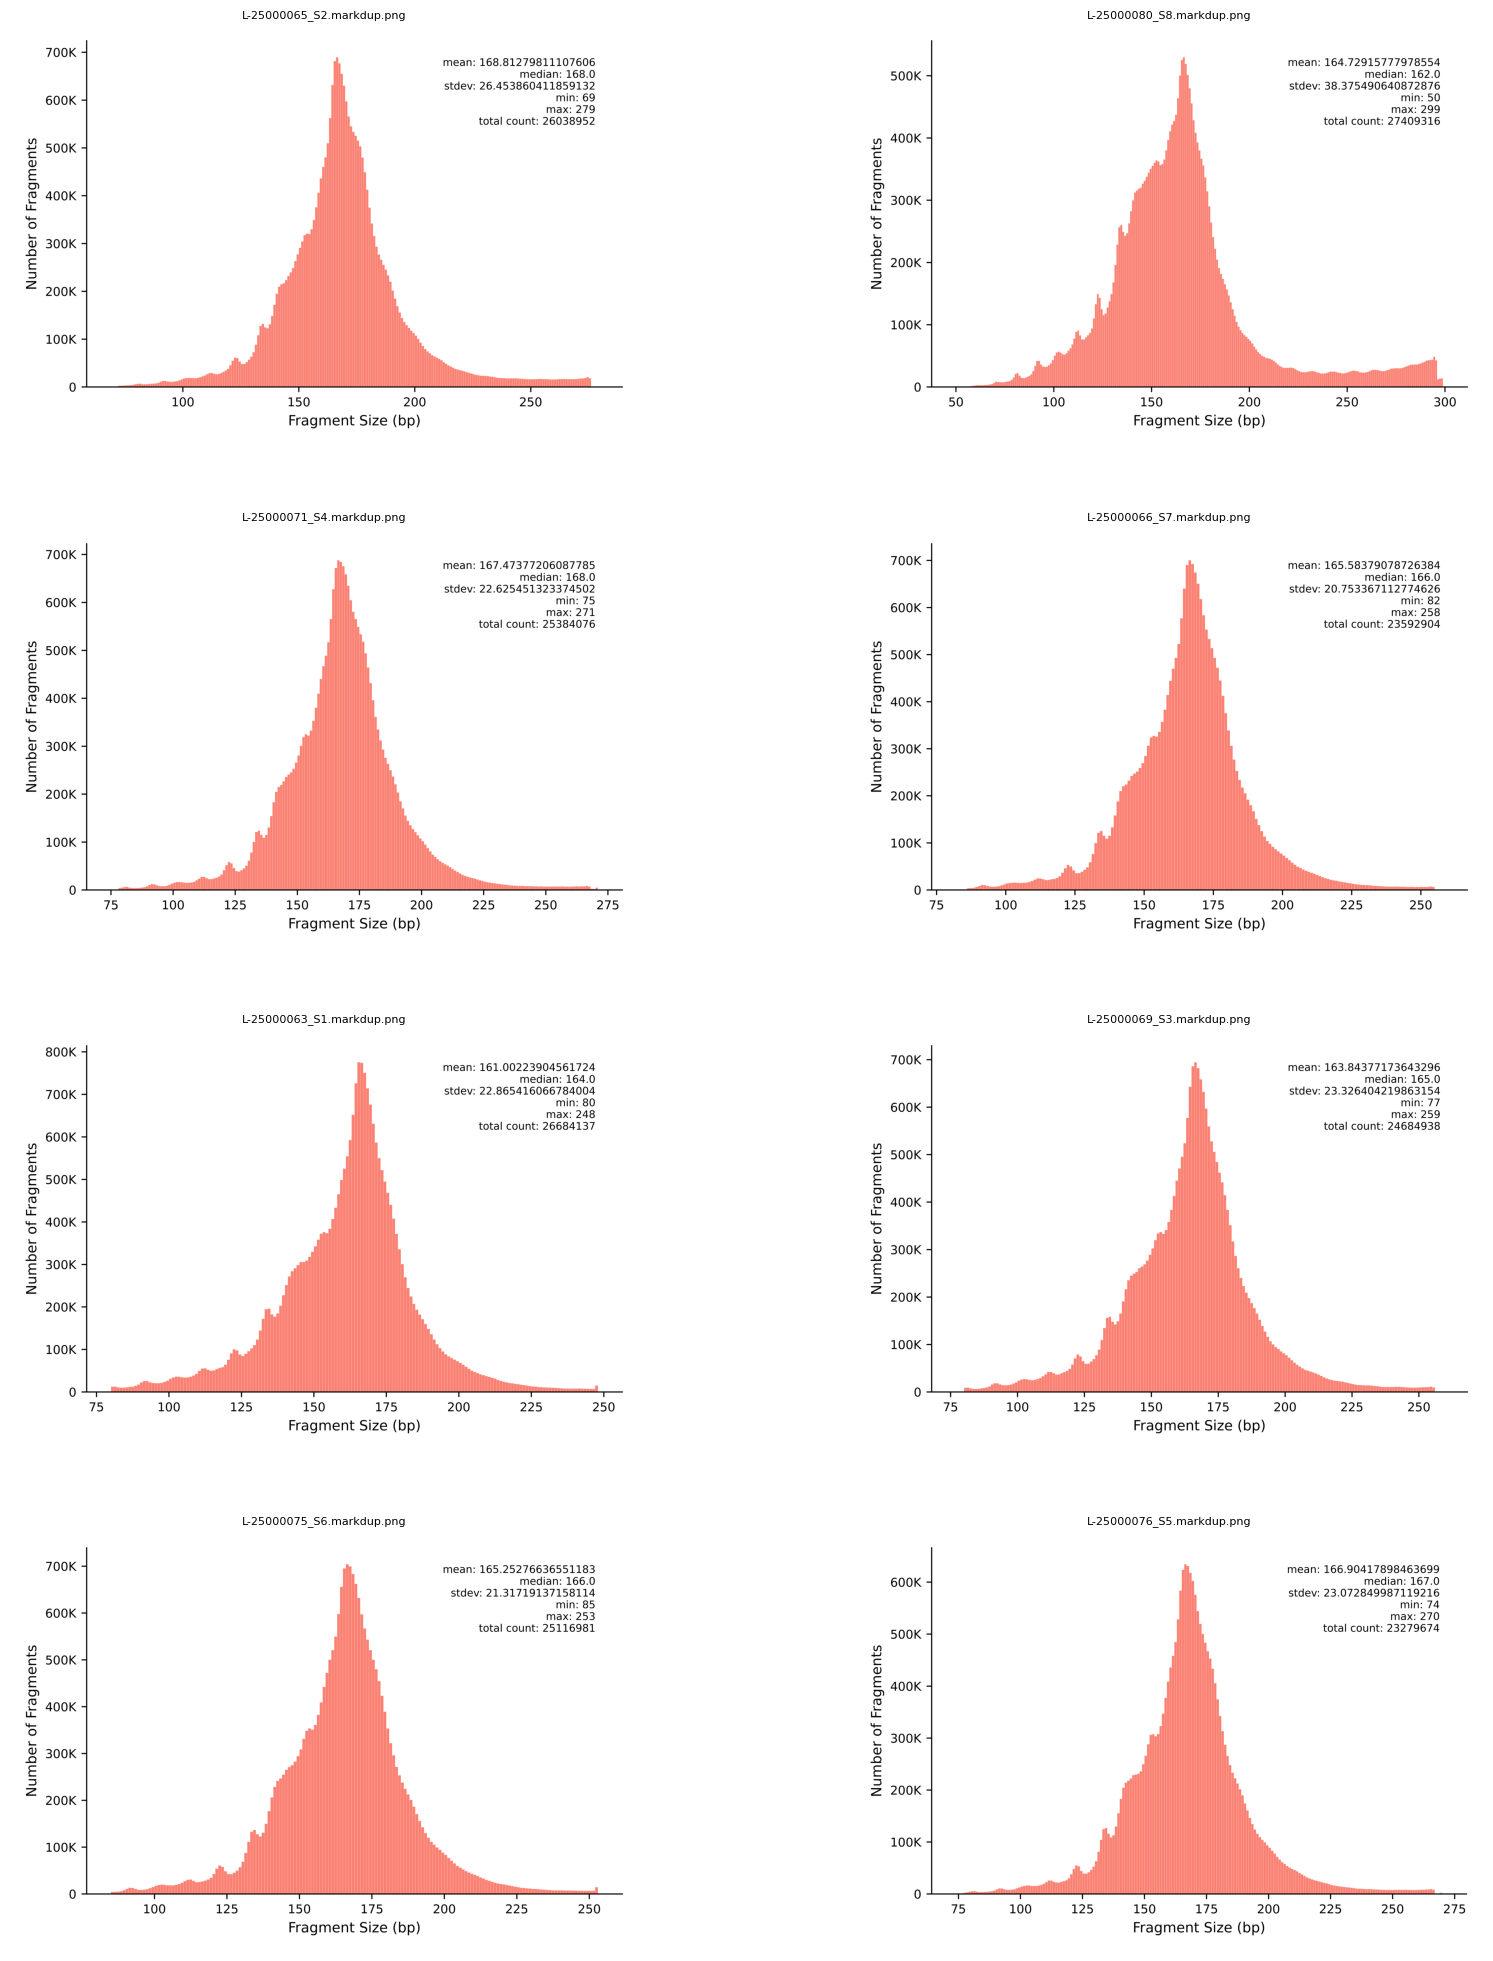

In [560]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pngfiles = glob.glob('results/01_fragment_lengths/*.png')

# defino panel 
fig, axes = plt.subplots(4, 2, figsize=(20, 25))

# flatten ejes
axes = axes.flatten()

# lista a rellenar con archivos de pool-527
pngfiles = []

for filename in glob.glob("results/01_fragment_lengths/*.markdup.png"):
    
    samplename = os.path.basename(filename).replace(".markdup.png", "")
    #print(samplename)
    #print(os.path.basename(filename))
    
    if samplename in list_pool527:
        #print(samplename)

        # anyadir filename entero a lista
        pngfiles.append(filename)

print(pngfiles)

# iteramos en axis e imagenes
for ax, img_path in zip(axes, pngfiles):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")  # no ticks or frames

    # saco el nombre
    fname = os.path.basename(img_path)

    # cogo lo de antes de .bam
    title = fname.split(".bam")[0]

    # Set the subplot title
    ax.set_title(title, fontsize=8)

### Ejemplo muestras NSCLC post-QC

Archivos .filtered.png

['results/01_fragment_lengths/L-25000065_S2.filtered.png', 'results/01_fragment_lengths/L-25000066_S7.filtered.png', 'results/01_fragment_lengths/L-25000075_S6.filtered.png', 'results/01_fragment_lengths/L-25000069_S3.filtered.png', 'results/01_fragment_lengths/L-25000063_S1.filtered.png', 'results/01_fragment_lengths/L-25000080_S8.filtered.png', 'results/01_fragment_lengths/L-25000076_S5.filtered.png', 'results/01_fragment_lengths/L-25000071_S4.filtered.png']


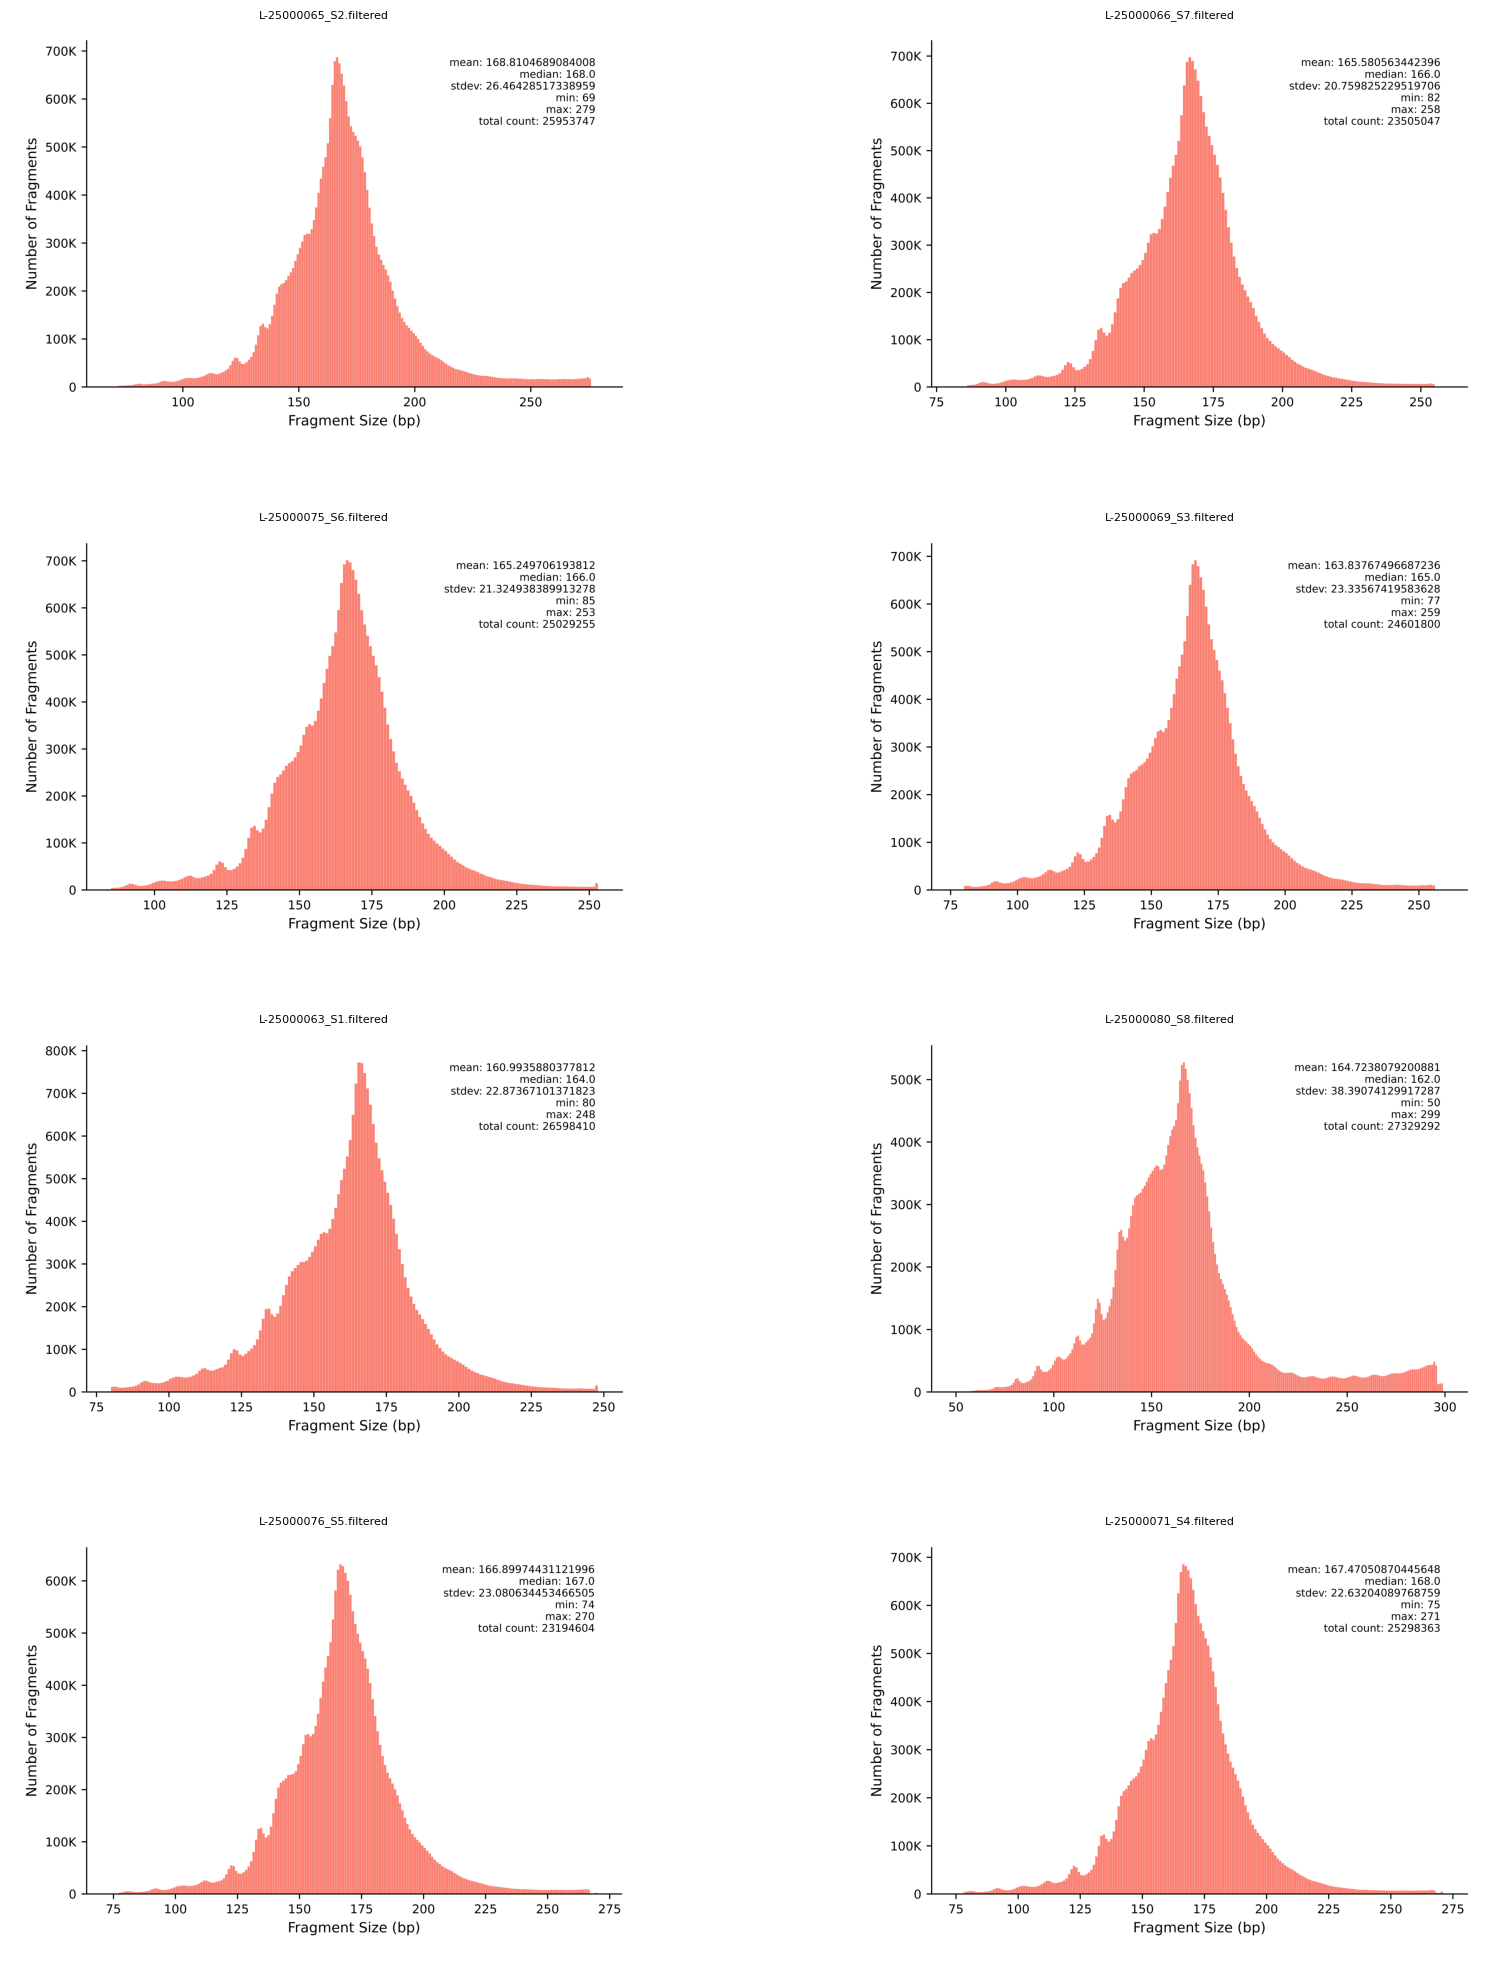

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# defino panel 
fig, axes = plt.subplots(4, 2, figsize=(20, 25))

# flatten ejes
axes = axes.flatten()

# lista a rellenar con archivos de pool-527
pngfiles = []

for filename in glob.glob("results/01_fragment_lengths/*.filtered.png"):
    
    samplename = os.path.basename(filename).replace(".filtered.png", "")
    #print(samplename)
    #print(os.path.basename(filename))
    
    if samplename in list_pool527:
        #print(samplename)

        # anyadir filename entero a lista
        pngfiles.append(filename)

print(pngfiles)

# iteramos en axis e imagenes
for ax, img_path in zip(axes, pngfiles):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")  # no ticks or frames

    # saco el nombre
    fname = os.path.basename(img_path)

    # cogo lo de antes de .png para identificar filtrado
    title = fname.split(".png")[0]

    # titulo
    ax.set_title(title, fontsize=8)

* Vemos que hay distinta densidad de fragmentos de diferentes tamaños (la mayoría de lecturas en fragmentos con tamaño medio/modal - 166). Por tanto, los duplicados tampoco estan uniformemente distribuidos a lo largo de los fragmentos y necesitaremos calcular la frequencia relativa para poder comparar la distribución de fragmentos antes y después del QC.

## Comandos Git ignorar reference file

In [ ]:
#git rm --cached hg38.2bit
#git remote add origin git@github.com:sara-suarez93/bcltofragmentomics.git
#git push --force
#git push --set-upstream origin main
#git push --force

## Motivos de corte

In [ ]:
# script 01_fragment_lengths.py
# bsub -o logs_hpc/out_endmot.txt -e logs_hpc/err_endmot.txt -q bio -n 1 -W 1400 -M 64000 -hl -R 'rusage[mem=64000]' python scripts/02_endmotifs.py

# Preprocesado de los datos

## Histogramas conteos

In [593]:
#del df_fraglen

In [592]:
#df_fraglen

In [10]:
import glob
import pandas as pd
# uno .tsv pre- y post-qc
df_fraglen = []

for f in glob.glob("results/01_fragment_lengths/*.tsv"):
    df = pd.read_csv(f, sep="\t")

    sample = os.path.basename(f).split(".")[0]
    #print(sample)
    qc = "post" if "filtered" in f else "pre"

    df["sample"] = sample
    df["qc"] = qc

    df_fraglen.append(df)

df_fraglen = pd.concat(df_fraglen, ignore_index=True)

df_fraglen.head()

,min,max,count,sample,qc
0,65,65,4,L-25000049_S4,post
1,66,66,870,L-25000049_S4,post
2,67,67,987,L-25000049_S4,post
3,68,68,1173,L-25000049_S4,post
4,69,69,10416,L-25000049_S4,post


In [11]:
df_fraglen['qc'].value_counts()

qc
post    10953
pre     10953
Name: count, dtype: int64

In [12]:
df_total = (
    df_fraglen.groupby(["sample", "qc"], as_index=False)["count"]
    .sum()
)

df_wide = (
    df_total
    .pivot(index="sample", columns="qc", values="count")
)

# ordenar por total por muestra (suma por fila) - muestra en indice
df_wide = df_wide.loc[df_wide.sum(axis=1).sort_values(ascending=False).index]

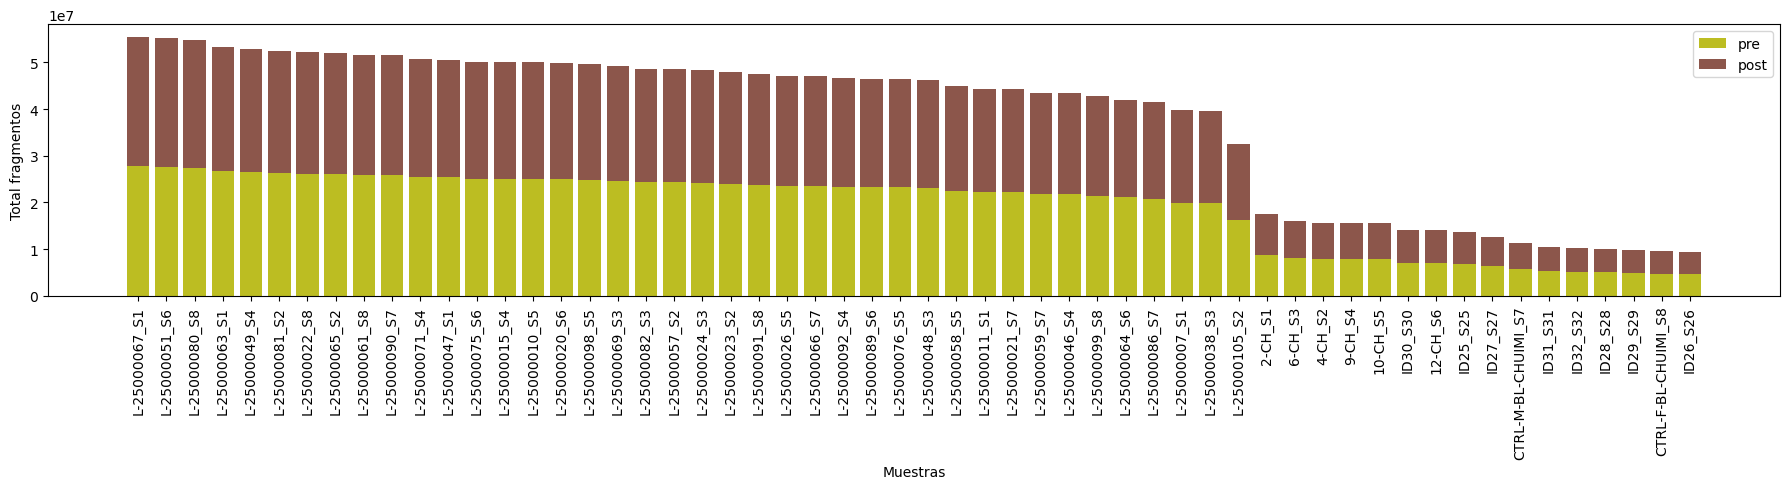

In [14]:
import matplotlib.pyplot as plt

colors_qc = {
    "pre": "tab:olive",
    "post": "tab:brown"
}

fig, ax = plt.subplots(figsize=(18, 5))

# bar pre
ax.bar(
    df_wide.index,
    df_wide["pre"],
    label="pre",
    color=colors_qc['pre']
)

# bar post encima
ax.bar(
    df_wide.index,
    df_wide["post"],
    bottom=df_wide["pre"], # dibujar barra post encima pre
    label="post",
    color=colors_qc['post']
)

ax.set_xlabel("Muestras")
ax.set_ylabel("Total fragmentos")

ax.tick_params(axis="x", rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
# frecuencia relativa - numero de fragmentos de x tamanyo/numero total por muestra
df_fraglen["rel_freq"] = (
    df_fraglen["count"] /
    # suma numero total para cada muestra
    df_fraglen.groupby(["sample", "qc"])["count"].transform("sum")
)

df_fraglen["scaled_freq"] = (
    # min-media/std
     (df_fraglen["rel_freq"]- df_fraglen.groupby("min")["rel_freq"].transform("mean")) / 
    df_fraglen.groupby("min")["rel_freq"].transform("std")
)

# conteos escalados
df_fraglen["scaled_count"] = (
    # min-media/std
     (df_fraglen["count"]- df_fraglen.groupby("min")["count"].transform("mean")) / 
    df_fraglen.groupby("min")["count"].transform("std")
)


df_fraglen.head()

,min,max,count,sample,qc,rel_freq,scaled_freq,scaled_count
0,65,65,4,L-25000049_S4,post,1.515868e-07,-0.854557,-0.931859
1,66,66,870,L-25000049_S4,post,3.297013e-05,-0.677005,-0.610566
2,67,67,987,L-25000049_S4,post,3.740405e-05,-0.639620,-0.563663
3,68,68,1173,L-25000049_S4,post,4.445283e-05,-0.674418,-0.591065
4,69,69,10416,L-25000049_S4,post,3.947321e-04,0.690074,1.735817


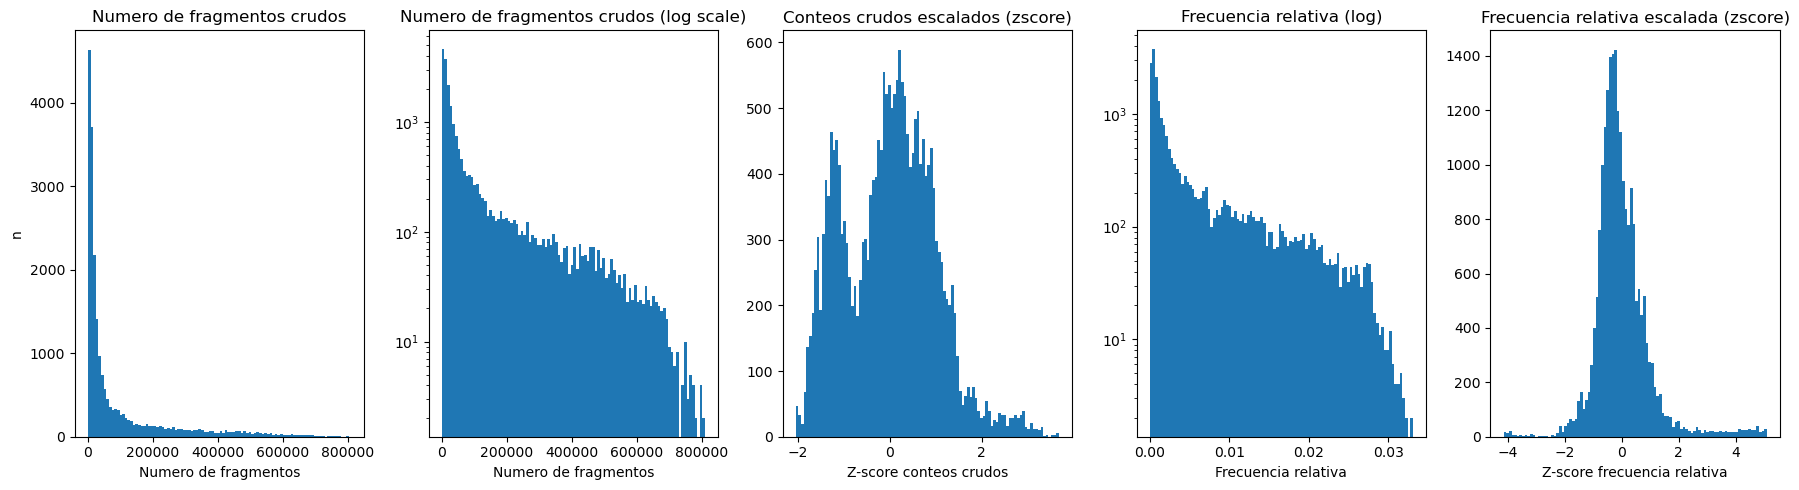

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)

# conteos crudos
axes[0].hist(
    df_fraglen["count"],
    bins=100
)

axes[0].set_title("Numero de fragmentos crudos")
axes[0].set_xlabel("Numero de fragmentos")
axes[0].set_ylabel("n")

# log trans
axes[1].hist(
    df_fraglen["count"],
    bins=100,
    log=True
)

# log en frecuencias relativas
axes[1].set_title("Numero de fragmentos crudos (log scale)")
axes[1].set_xlabel("Numero de fragmentos")

# escalado conteos crudos
axes[2].hist(
    df_fraglen["scaled_count"],
    bins=100
)

axes[2].set_xlabel("Z-score conteos crudos")
axes[2].set_title("Conteos crudos escalados (zscore)")

axes[3].hist(
    df_fraglen["rel_freq"],
    bins=100,
    log=True
)

axes[3].set_title("Frecuencia relativa (log)")
axes[3].set_xlabel("Frecuencia relativa")

# escalado rel freqs
axes[4].hist(
    df_fraglen["scaled_freq"],
    bins=100
)

axes[4].set_xlabel("Z-score frecuencia relativa")
axes[4].set_title("Frecuencia relativa escalada (zscore)")

plt.tight_layout()
plt.show()

## PCA pre. vs post-QC

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# PCA-rel freqs
mat_fraglen = (
    df_fraglen
    .pivot_table(
        index=["sample", "qc"],
        columns="min",        # fragment length
        values="rel_freq",
        fill_value=0)
)
pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen)

df_pca = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen.index)
    .reset_index()
)
df_pca.head()

,sample,qc,PC1,PC2
0,10-CH_S5,post,0.012766,-0.014611
1,10-CH_S5,pre,0.012760,-0.014635
2,12-CH_S6,post,0.012324,-0.012645
3,12-CH_S6,pre,0.012325,-0.012673
4,2-CH_S1,post,-0.021316,0.028088


In [18]:
mat_fraglen_scaled = (
    df_fraglen
    .pivot_table(
        index=["sample", "qc"],
        columns="min",        # fragment length
        values="scaled_freq",
        fill_value=0)
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen_scaled)

df_pca_scaled = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen_scaled.index)
    .reset_index()
)
df_pca_scaled.head()

,sample,qc,PC1,PC2
0,10-CH_S5,post,-6.280172,9.720016
1,10-CH_S5,pre,-6.270670,9.729166
2,12-CH_S6,post,-6.444985,7.806219
3,12-CH_S6,pre,-6.440481,7.815257
4,2-CH_S1,post,0.774564,-18.680985


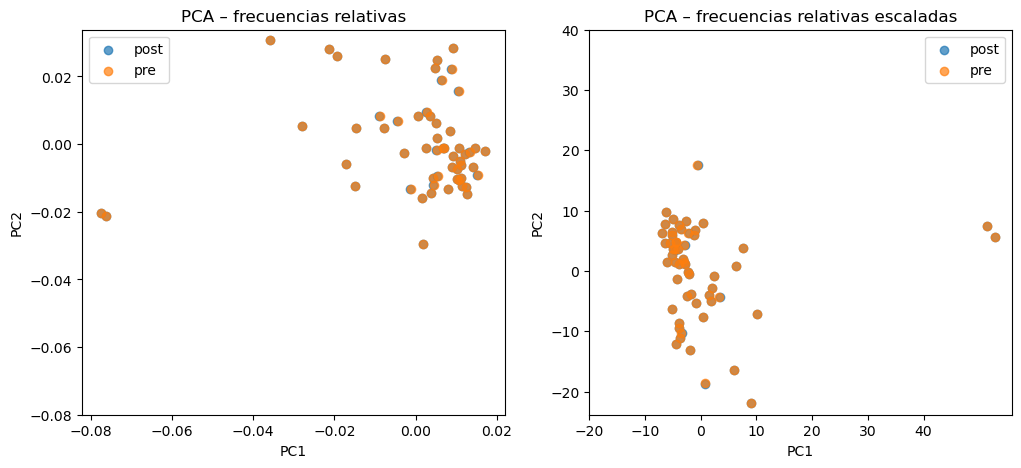

In [20]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# frecuencias relativas
for qc, g in df_pca.groupby("qc"):
    axes[0].scatter(g.PC1, g.PC2, label=qc, alpha=0.7)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_xticks(np.arange(-0.08, 0.03, 0.02))
axes[0].set_yticks(np.arange(-0.08, 0.03, 0.02))
axes[0].set_title("PCA – frecuencias relativas")
axes[0].legend()

# escalados
for qc, g in df_pca_scaled.groupby("qc"):
    axes[1].scatter(g.PC1, g.PC2, label=qc, alpha=0.7)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_xticks(np.arange(-20, 50, 10))
axes[1].set_yticks(np.arange(-20, 50, 10))
axes[1].set_title("PCA – frecuencias relativas escaladas")
axes[1].legend()

In [21]:
# outliers
df_pca_scaled.sort_values(by="PC1", ascending=False).head()

,sample,qc,PC1,PC2
14,CTRL-M-BL-CHUIMI_S7,post,52.859347,5.578969
15,CTRL-M-BL-CHUIMI_S7,pre,52.832767,5.606263
12,CTRL-F-BL-CHUIMI_S8,post,51.380720,7.445563
13,CTRL-F-BL-CHUIMI_S8,pre,51.360148,7.478077
90,L-25000080_S8,post,10.165339,-7.141910


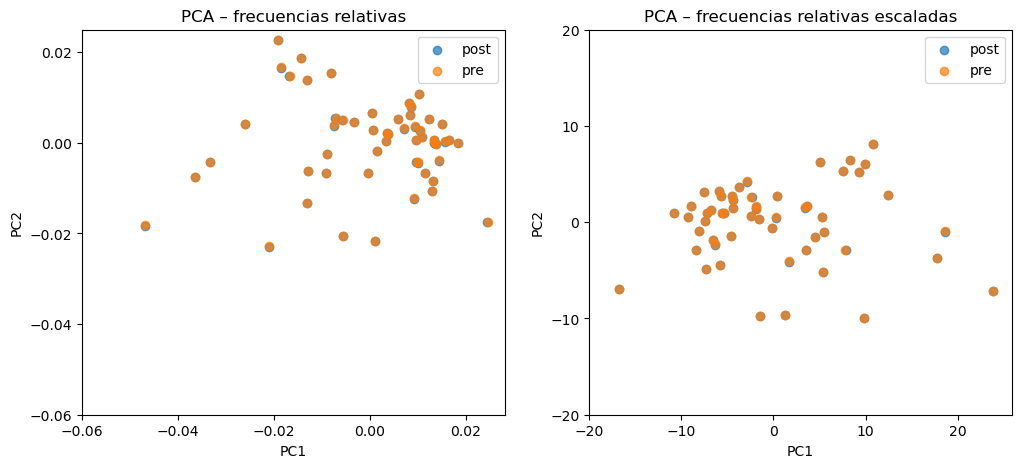

In [22]:
# excluding controls
ctrl_samples = ["CTRL-M-BL-CHUIMI_S7", "CTRL-F-BL-CHUIMI_S8"]

# exclude them
df_fraglen = df_fraglen[~df_fraglen["sample"].isin(ctrl_samples)]

# remake PCAs
mat_fraglen = (
    df_fraglen
    .pivot_table(
        index=["sample", "qc"],
        columns="min",        # fragment length
        values="rel_freq",
        fill_value=0)
)
pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen)

df_pca = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen.index)
    .reset_index()
)

# escalada
mat_fraglen_scaled = (
    df_fraglen
    .pivot_table(
        index=["sample", "qc"],
        columns="min",        # fragment length
        values="scaled_freq",
        fill_value=0)
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen_scaled)

df_pca_scaled = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen_scaled.index)
    .reset_index()
)

# representar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# frecuencias relativas
for qc, g in df_pca.groupby("qc"):
    axes[0].scatter(g.PC1, g.PC2, label=qc, alpha=0.7)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_xticks(np.arange(-0.06, 0.03, 0.02))
axes[0].set_yticks(np.arange(-0.06, 0.03, 0.02))
axes[0].set_title("PCA – frecuencias relativas")
axes[0].legend()

# escalados
for qc, g in df_pca_scaled.groupby("qc"):
    axes[1].scatter(g.PC1, g.PC2, label=qc, alpha=0.7)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_xticks(np.arange(-20, 30, 10))
axes[1].set_yticks(np.arange(-20, 30, 10))
axes[1].set_title("PCA – frecuencias relativas escaladas")
axes[1].legend()

## PCA batch

In [23]:
dic_pool_muestras = {"POOL-551N": ["L-25000067", "L-25000081", "L-25000082", "L-25000092",
                                   "L-25000098", "L-25000089", "L-25000090", "L-25000091"],
                     
                     "POOL-496N": ["L-25000047", "L-25000057", "L-25000048", "L-25000049",
                                   "L-25000058", "L-25000051", "L-25000059", "L-25000061"],
                     
                     "POOL-401N": ["2-CH", "4-CH", "6-CH", "9-CH",
                                   "10-CH", "12-CH"#,
                                   #"CTRL-M-BL-CHUIMI", "CTRL-F-BL-CHUIMI"
                                  ],
                     
                     "POOL-473N": ["L-25000011", "L-25000023", "L-25000024", "L-25000015",
                                   "L-25000010", "L-25000020", "L-25000021", "L-25000022"],
                     
                     "POOL-479N": [#"ID1", "ID2", "ID3", "ID4", "ID5", "ID6", "ID7", "ID8",
                                   #"ID9", "ID10", "ID11", "ID12", "ID13", "ID14", "ID15", "ID16",
                                   #"ID17", "ID18", "ID19", "ID20", "ID21", "ID22", "ID23", "ID24",
                                   "ID25", "ID26", "ID27", "ID28", "ID29", "ID30", "ID31", "ID32"],
                     
                     "POOL-527N": ["L-25000063", "L-25000065", "L-25000069", "L-25000071",
                                   "L-25000076", "L-25000075", "L-25000066", "L-25000080"],
                     
                     "POOL-546N": ["L-25000007", "L-25000105", "L-25000038", "L-25000046",
                                   "L-25000026", "L-25000064", "L-25000086", "L-25000099"]
                    }

In [24]:
# lookup: muestra para cada pool
sample_to_pool = {
    # muestra ahora es key
    sample: pool
    # muestras es la lista
    for pool, samples in dic_pool_muestras.items()
    # para cada muestra de la lista - key value
    for sample in samples
}

#print(sample_to_pool)

In [25]:
df_fraglen.loc[:, "pool"] = df_fraglen['sample'].str.split("_").str[0].map(sample_to_pool)

print(df_fraglen.head())

# all ok! - no NA
df_fraglen["pool"].isna().any()

   min  max  count         sample    qc      rel_freq  scaled_freq  \
0   65   65      4  L-25000049_S4  post  1.515868e-07    -0.854557   
1   66   66    870  L-25000049_S4  post  3.297013e-05    -0.677005   
2   67   67    987  L-25000049_S4  post  3.740405e-05    -0.639620   
3   68   68   1173  L-25000049_S4  post  4.445283e-05    -0.674418   
4   69   69  10416  L-25000049_S4  post  3.947321e-04     0.690074   

   scaled_count       pool  
0     -0.931859  POOL-496N  
1     -0.610566  POOL-496N  
2     -0.563663  POOL-496N  
3     -0.591065  POOL-496N  
4      1.735817  POOL-496N  


np.False_

In [26]:
df_fraglen.head()

,min,max,count,sample,qc,rel_freq,scaled_freq,scaled_count,pool
0,65,65,4,L-25000049_S4,post,1.515868e-07,-0.854557,-0.931859,POOL-496N
1,66,66,870,L-25000049_S4,post,3.297013e-05,-0.677005,-0.610566,POOL-496N
2,67,67,987,L-25000049_S4,post,3.740405e-05,-0.639620,-0.563663,POOL-496N
3,68,68,1173,L-25000049_S4,post,4.445283e-05,-0.674418,-0.591065,POOL-496N
4,69,69,10416,L-25000049_S4,post,3.947321e-04,0.690074,1.735817,POOL-496N


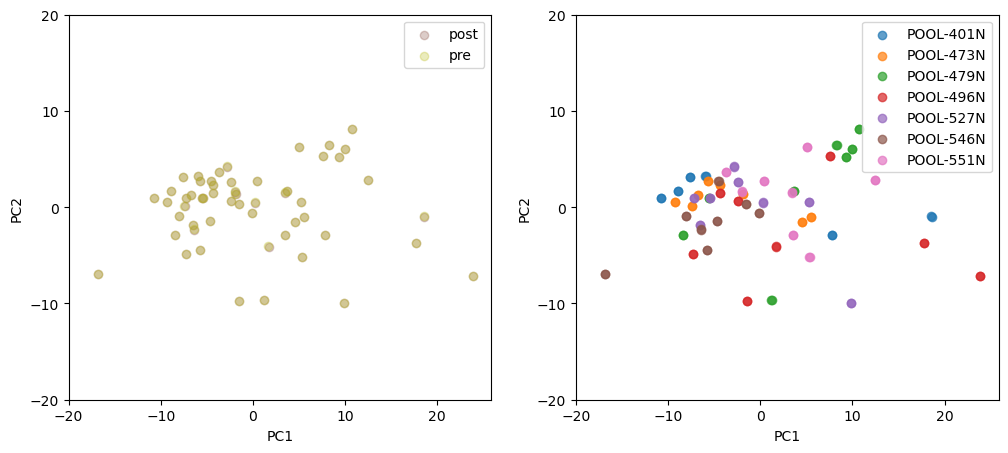

In [27]:
mat_fraglen = (
    df_fraglen.pivot_table(
        index=["sample", "qc", "pool"],
        columns="min",        # fragment length
        values="scaled_freq",
        fill_value=0)
)
pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen)

df_pca = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen.index)
    .reset_index()
)

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors_qc = {
    "pre": "tab:olive",
    "post": "tab:brown"
}


# escalados
for qc, g in df_pca.groupby("qc"):
    axes[0].scatter(g.PC1, g.PC2, 
                    label=qc, 
                    alpha=0.3,
                    color=colors_qc[qc])

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_xticks(np.arange(-20, 30, 10))
axes[0].set_yticks(np.arange(-20, 30, 10))
#axes[0].set_title("PCA – frecuencias relativas escaladas")
axes[0].legend()

for pool, g in df_pca.groupby("pool"):
    axes[1].scatter(g.PC1, g.PC2, label=pool, alpha=0.7)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_xticks(np.arange(-20, 30, 10))
axes[1].set_yticks(np.arange(-20, 30, 10))
#ax.set_title("PCA – frecuencia escalada")
axes[1].legend()

plt.show()

# Análisis

## PCA colon vs NSCL

In [45]:
# datos colon Ivan
li = []

for filename in os.listdir("../UOC/TFM/00_datos/fragmentomics_colon_lesende"):
    # archivos histograma fraglen 
    if filename.endswith(".tsv") and 'histo' in filename:
        #print(filename)
        df = pd.read_csv(os.path.join("../UOC/TFM/00_datos/fragmentomics_colon_lesende", filename), 
                         index_col=None, 
                         sep='\t'
        )
        li.append(df)
        #print(df.head())
        # anyadir nombre archivo a columna
        filename = filename.split(".bam")[0]
        #print(filename)
        df['sample'] = filename
        
df_colon = pd.concat(li, axis=0, ignore_index=True)

df_colon["rel_freq"] = (
    df_colon["count"] /
    # suma numero total para cada muestra
    df_colon.groupby(["sample"])["count"].transform("sum")
)

df_colon["scaled_freq"] = (    
    # min-media/std
     (df_colon["rel_freq"]- df_colon.groupby("min")["rel_freq"].transform("mean")) / 
    df_colon.groupby("min")["rel_freq"].transform("std")
)

# anyadir colon
df_colon["cancer_type"] = "colon"

print(df_colon.head())

   min  max  count                 sample  rel_freq  scaled_freq cancer_type
0   50   51    420  histoCas4826cf-16colh  0.000028    -0.214863       colon
1   52   53    436  histoCas4826cf-16colh  0.000029    -0.236896       colon
2   54   55    566  histoCas4826cf-16colh  0.000037    -0.264358       colon
3   56   57    894  histoCas4826cf-16colh  0.000059    -0.271737       colon
4   58   59   1545  histoCas4826cf-16colh  0.000102    -0.273877       colon


In [46]:
# df NSCLC
print(df_fraglen.head())

   min  max  count         sample    qc      rel_freq  scaled_freq  \
0   65   65      4  L-25000049_S4  post  1.515868e-07    -0.854557   
1   66   66    870  L-25000049_S4  post  3.297013e-05    -0.677005   
2   67   67    987  L-25000049_S4  post  3.740405e-05    -0.639620   
3   68   68   1173  L-25000049_S4  post  4.445283e-05    -0.674418   
4   69   69  10416  L-25000049_S4  post  3.947321e-04     0.690074   

   scaled_count       pool  
0     -0.931859  POOL-496N  
1     -0.610566  POOL-496N  
2     -0.563663  POOL-496N  
3     -0.591065  POOL-496N  
4      1.735817  POOL-496N  


In [47]:
#### combinar datos
df_nsclc = df_fraglen[df_fraglen['qc'] == 'post'].copy()

df_nsclc['cancer_type'] = 'NSCLC'

df_nsclc = df_nsclc[['min', 'max', 'count', 'sample', 'rel_freq', 'scaled_freq', 'cancer_type']]

# unir a colon
df_fraglen_all = pd.concat([df_nsclc, df_colon], ignore_index=True)

print(df_fraglen_all.head())

# guardar excel
import openpyxl
df_fraglen_all.to_excel("data_fragment_length_nlsclc_colon.xlsx", index = False)

   min  max  count         sample      rel_freq  scaled_freq cancer_type
0   65   65      4  L-25000049_S4  1.515868e-07    -0.854557       NSCLC
1   66   66    870  L-25000049_S4  3.297013e-05    -0.677005       NSCLC
2   67   67    987  L-25000049_S4  3.740405e-05    -0.639620       NSCLC
3   68   68   1173  L-25000049_S4  4.445283e-05    -0.674418       NSCLC
4   69   69  10416  L-25000049_S4  3.947321e-04     0.690074       NSCLC


In [34]:
num_muestras_tumor = (
    df_fraglen_all[["sample", "cancer_type"]]
    .drop_duplicates()
    .groupby("cancer_type")
    .size()
)

num_muestras_tumor

cancer_type
NSCLC    54
colon    21
dtype: int64

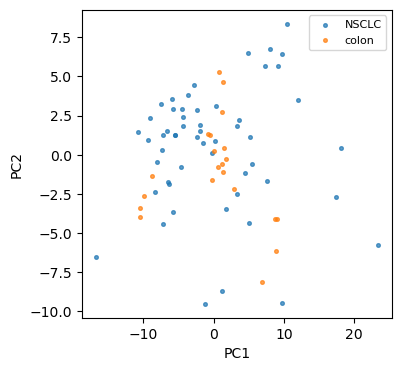

In [711]:
mat_fraglen_all = (
    df_fraglen_all.pivot_table(
        index=["sample", "cancer_type"],
        columns="min",        # fragment length
        values="scaled_freq",
        fill_value=0)
)
pca = PCA(n_components=2)
pcs = pca.fit_transform(mat_fraglen_all)

df_pca = (
    pd.DataFrame(pcs, columns=["PC1", "PC2"], index=mat_fraglen_all.index)
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(4, 4))

for cancer_type, g in df_pca.groupby("cancer_type"):
    ax.scatter(g.PC1, g.PC2, 
               label=cancer_type, 
               alpha=0.7,
                s = 7
              )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
#ax.set_xticks(np.arange(-20, 30, 10))
#ax.set_yticks(np.arange(-20, 30, 10))
#ax.set_title("PCA – frecuencia escalada")
ax.legend(fontsize=8)

plt.show()

## Longitud de motivos

In [35]:
df_perfil = (
    df_fraglen_all.groupby(["cancer_type", "min"], as_index=False)["count"].sum()
)

df_perfil["count_per_sample"] = (
    df_perfil["count"] /
    df_perfil["cancer_type"].map(num_muestras_tumor)
)

print(df_perfil.head())

  cancer_type  min  count  count_per_sample
0       NSCLC   50   2597         48.092593
1       NSCLC   51   4162         77.074074
2       NSCLC   52   4344         80.444444
3       NSCLC   53   4741         87.796296
4       NSCLC   54   5508        102.000000


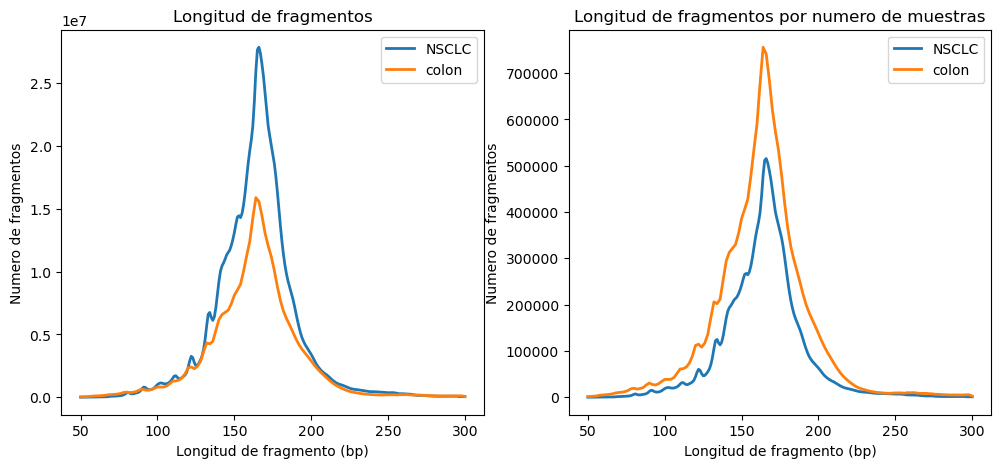

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax[0].plot(
        g["min"],
        g["count"],
        label=tumor,
        linewidth=2
    )

ax[0].set_xlabel("Longitud de fragmento (bp)")
ax[0].set_ylabel("Numero de fragmentos")
ax[0].set_title("Longitud de fragmentos")
ax[0].legend()

for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax[1].plot(
        g["min"],
        g["count_per_sample"],
        label=tumor,
        linewidth=2
    )

ax[1].set_xlabel("Longitud de fragmento (bp)")
ax[1].set_ylabel("Numero de fragmentos")
ax[1].set_title("Longitud de fragmentos por numero de muestras")
ax[1].legend()

plt.show()

In [714]:
df_perfil.head()

,tumor_type,min,count,count_per_sample
0,NSCLC,50,2597,48.092593
1,NSCLC,51,4162,77.074074
2,NSCLC,52,4344,80.444444
3,NSCLC,53,4741,87.796296
4,NSCLC,54,5508,102.000000


/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_9769/1849725221.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.loc[g["count"].idxmax(), "min"])


['NSCLC (moda = 165.0 bp)', 'colon (moda = 164.0 bp)']


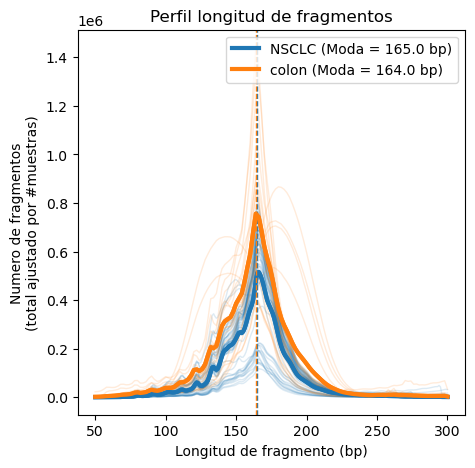

In [720]:
colors_tumor = {
    "NSCLC": "tab:blue",
    "colon": "tab:orange"
}

# perfil por muestra
df_perfil_sample = (
    df_fraglen_all
    .groupby(["cancer_type", "sample", "min"], as_index=False)["count"]
    .sum()
)

# media longitud de fragmentos
mean_fraglen = (
    df_perfil_sample
    .groupby("cancer_type")
    .apply(lambda g: np.average(g["min"], weights=g["count"]), include_groups=False)
)

# moda longitud de fragmentos
mode_fraglen = (
    df_perfil_sample
    .groupby("cancer_type", group_keys=False)
    .apply(lambda g: g.loc[g["count"].idxmax(), "min"])
)

legend_labels = []

for tumor, x in mode_fraglen.items():
    legend_labels.append(f"{tumor} (moda = {x:.1f} bp)")

print(legend_labels)

fig, ax = plt.subplots(figsize=(5, 5))

# perfil por muestra
for (tumor, sample), g in df_perfil_sample.groupby(["cancer_type", "sample"]):
    g = g.sort_values("min")
    ax.plot(
        g["min"],
        g["count"],
        color=colors_tumor[tumor],
        alpha=0.15,       # faint
        linewidth=1
    )

# perfil medio por tumor (ajustado a numero de muestras)
for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax.plot(
        g["min"],
        g["count_per_sample"],
        color=colors_tumor[tumor],
        linewidth=3,
        label="_nolegend_"
    )

# lineas media longitud fragmento
for tumor, g in df_perfil.groupby("cancer_type"):
    g = g.sort_values("min")
    ax.plot(
        g["min"],
        g["count_per_sample"],
        color=colors_tumor[tumor],
        linewidth=3,
        label=f"{tumor} (Moda = {mode_fraglen[tumor]:.1f} bp)"
    )

    ax.axvline(
        mode_fraglen[tumor],
        color=colors_tumor[tumor],
        linestyle="--",
        linewidth=1,
        label="_nolegend_"
    )

ax.set_xlabel("Longitud de fragmento (bp)")
ax.set_ylabel("Numero de fragmentos\n(total ajustado por #muestras)")
ax.set_title("Perfil longitud de fragmentos")
ax.legend()

plt.show()

## End-motifs

In [38]:
import re

# dataset con ambos
path_endmot_nsclc = os.path.join(results_endmot, "*.filtered.k4.tsv") 
path_endmot_colon = "../UOC/TFM/00_datos/fragmentomics_colon_lesende/*.tsv"
# hay que especificar los archivos de 4-mer (histo-fraglen y 2-2mer)
# if not os.path.basename(f).startswith(("histo", "2"))

# datos k=4 NSCLC
li = []

for filename in glob.glob(path_endmot_nsclc):
    samplename = re.sub(r'\.(bam\.tsv|filtered\.k4\.tsv)$', '', os.path.basename(filename))

    # archivos 4mer 
    #print(filename)
    df = pd.read_csv(filename, 
                     index_col=None,
                     names=["motif","freq"],
                     sep='\t')
    li.append(df)
    # anyadir nombre archivo a columna
    filename = filename.split(".bam")[0]
    df['sample'] = samplename
    df['cancer_type'] = "NSCLC"
    #print(df.head())
        
df_nsclc = pd.concat(li, axis=0, ignore_index=True)

print(df_nsclc.head())

  motif      freq         sample cancer_type
0  AAAA  0.010040  L-25000063_S1       NSCLC
1  AAAC  0.003083  L-25000063_S1       NSCLC
2  AAAG  0.004791  L-25000063_S1       NSCLC
3  AAAT  0.004994  L-25000063_S1       NSCLC
4  AACA  0.003264  L-25000063_S1       NSCLC


In [39]:
# datos colon
li = []

for filename in glob.glob(path_endmot_colon):
    samplename = re.sub(r'\.(bam\.tsv|filtered\.k4\.tsv)$', '', os.path.basename(filename))
    if samplename.startswith(("histo", "2")):
        continue
    # archivos 4mer 
    #print(filename)
    df = pd.read_csv(filename, 
                     index_col=None,
                     names=["motif","freq"],
                     sep='\t')
    li.append(df)
    # anyadir nombre archivo a columna
    filename = filename.split(".bam")[0]
    df['sample'] = samplename
    df['cancer_type'] = "colon"
    #print(df.head())
        
df_colon = pd.concat(li, axis=0, ignore_index=True)

print(df_colon.head())

  motif      freq        sample cancer_type
0  AAAA  0.009084  Cas5068cf(1)       colon
1  AAAC  0.002977  Cas5068cf(1)       colon
2  AAAG  0.005362  Cas5068cf(1)       colon
3  AAAT  0.004388  Cas5068cf(1)       colon
4  AACA  0.003822  Cas5068cf(1)       colon


In [40]:
df_endmot_all = pd.concat([df_nsclc, df_colon], ignore_index=True)

df_endmot_all = df_endmot_all[~df_endmot_all["sample"].isin(ctrl_samples)]

print(df_endmot_all["cancer_type"].value_counts())

cancer_type
NSCLC    13824
colon     5376
Name: count, dtype: int64


In [43]:
# guardar excel
import openpyxl
df_endmot_all.to_excel("data_endmotif_nlsclc_colon.xlsx", index = False)

In [41]:
df_endmot_all['freq'].min()

1.9567670756997536e-05

In [42]:
heat_matrix = df_endmot_all.pivot(index="motif", columns="sample", values="freq")
print(heat_matrix.head())

sample  10-CH_S5  12-CH_S6   2-CH_S1   4-CH_S2   6-CH_S3   9-CH_S4  \
motif                                                                
AAAA    0.010069  0.009915  0.011499  0.010979  0.010008  0.010312   
AAAC    0.003166  0.003287  0.004026  0.003868  0.004053  0.003165   
AAAG    0.004326  0.004539  0.005685  0.005560  0.005553  0.004335   
AAAT    0.004888  0.005142  0.007421  0.006828  0.006736  0.004891   
AACA    0.003541  0.003669  0.004189  0.004054  0.004329  0.003494   

sample  Cas4684cf-9colh  Cas4814cf-18colh  Cas4814cf-20colh  Cas4826cf-16colh  \
motif                                                                           
AAAA           0.009811          0.009682          0.009786          0.010318   
AAAC           0.003663          0.003338          0.003039          0.003364   
AAAG           0.005972          0.005713          0.005144          0.005671   
AAAT           0.004729          0.004367          0.004650          0.004465   
AACA           0.004782

/Users/sarasuarez/miniconda3/envs/fragmentomics/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


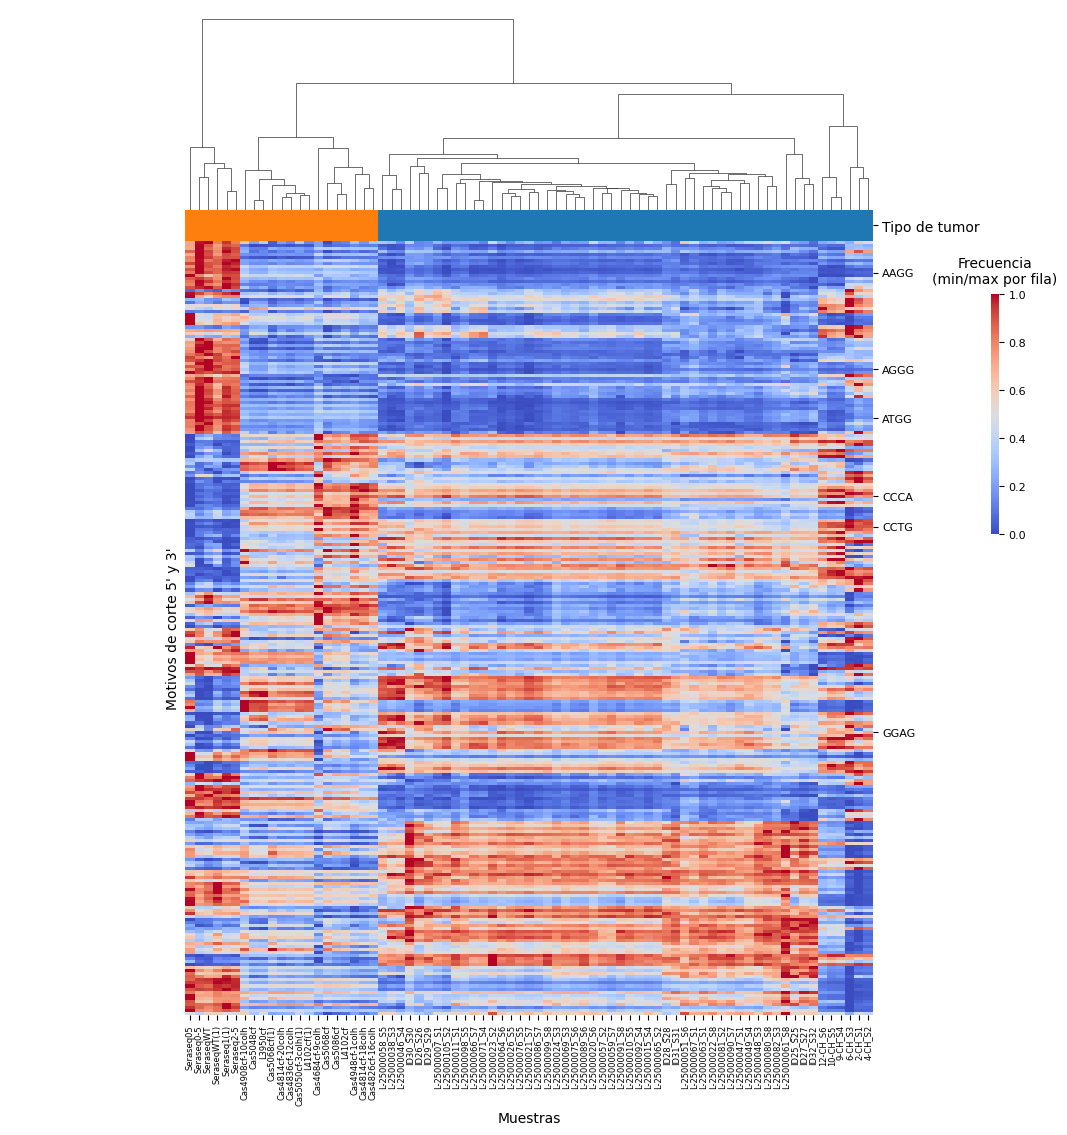

In [52]:
# heatmap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# matrix
heat_matrix = df_endmot_all.pivot(index="motif", columns="sample", values="freq")

# color
colors_tumor = {
    "NSCLC": "tab:blue",
    "colon": "tab:orange"
}
col_colors = df_endmot_all.drop_duplicates("sample").set_index("sample")["cancer_type"].map(colors_tumor)
# leyenda
col_colors.name = "Tipo de tumor"

# clustered heatmap
heat = sns.clustermap(
    heat_matrix,
    col_cluster=True,        
    row_cluster=False,
    col_colors=col_colors,
    cmap="coolwarm",
    standard_scale=0, # normalizar filas (max freq = 1 vs min freq = 0)
    figsize=(10,12),
    xticklabels=True,
    yticklabels=False
    #cbar_kws={"shrink": 0.2}
)

heat.ax_heatmap.tick_params(axis='x', labelsize=6)
heat.ax_heatmap.yaxis.set_label_position("left")
heat.ax_heatmap.set_ylabel("Motivos de corte 5' y 3'")
heat.ax_heatmap.set_xlabel("Muestras")

# nombre filas de motivos representativos
yticks = []
yticklabels = []

# motivos seleccionados - ver siguiente seccion
rep_motifs = ['CCTG', 'CCCA', 'GGAG',
              'AAGG', 'AGGG', 'ATGG'
             ]

for i, motif in enumerate(heat_matrix.index):
    if motif in rep_motifs:
        yticks.append(i + 0.5)      # center of the cell
        yticklabels.append(motif)

heat.ax_heatmap.set_yticks(yticks)
heat.ax_heatmap.set_yticklabels(yticklabels, fontsize=8)

# leyenda
heat.ax_cbar.set_aspect(30)
heat.ax_cbar.set_position([0.9, 0.55, 0.2, 0.2]) 
heat.ax_cbar.tick_params(labelsize=8)
heat.ax_cbar.set_title("Frecuencia\n(min/max por fila)", fontsize=10, pad=8)

plt.show()

/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60712/3993575285.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60712/3993575285.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60712/3993575285.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_60712/3993575285.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

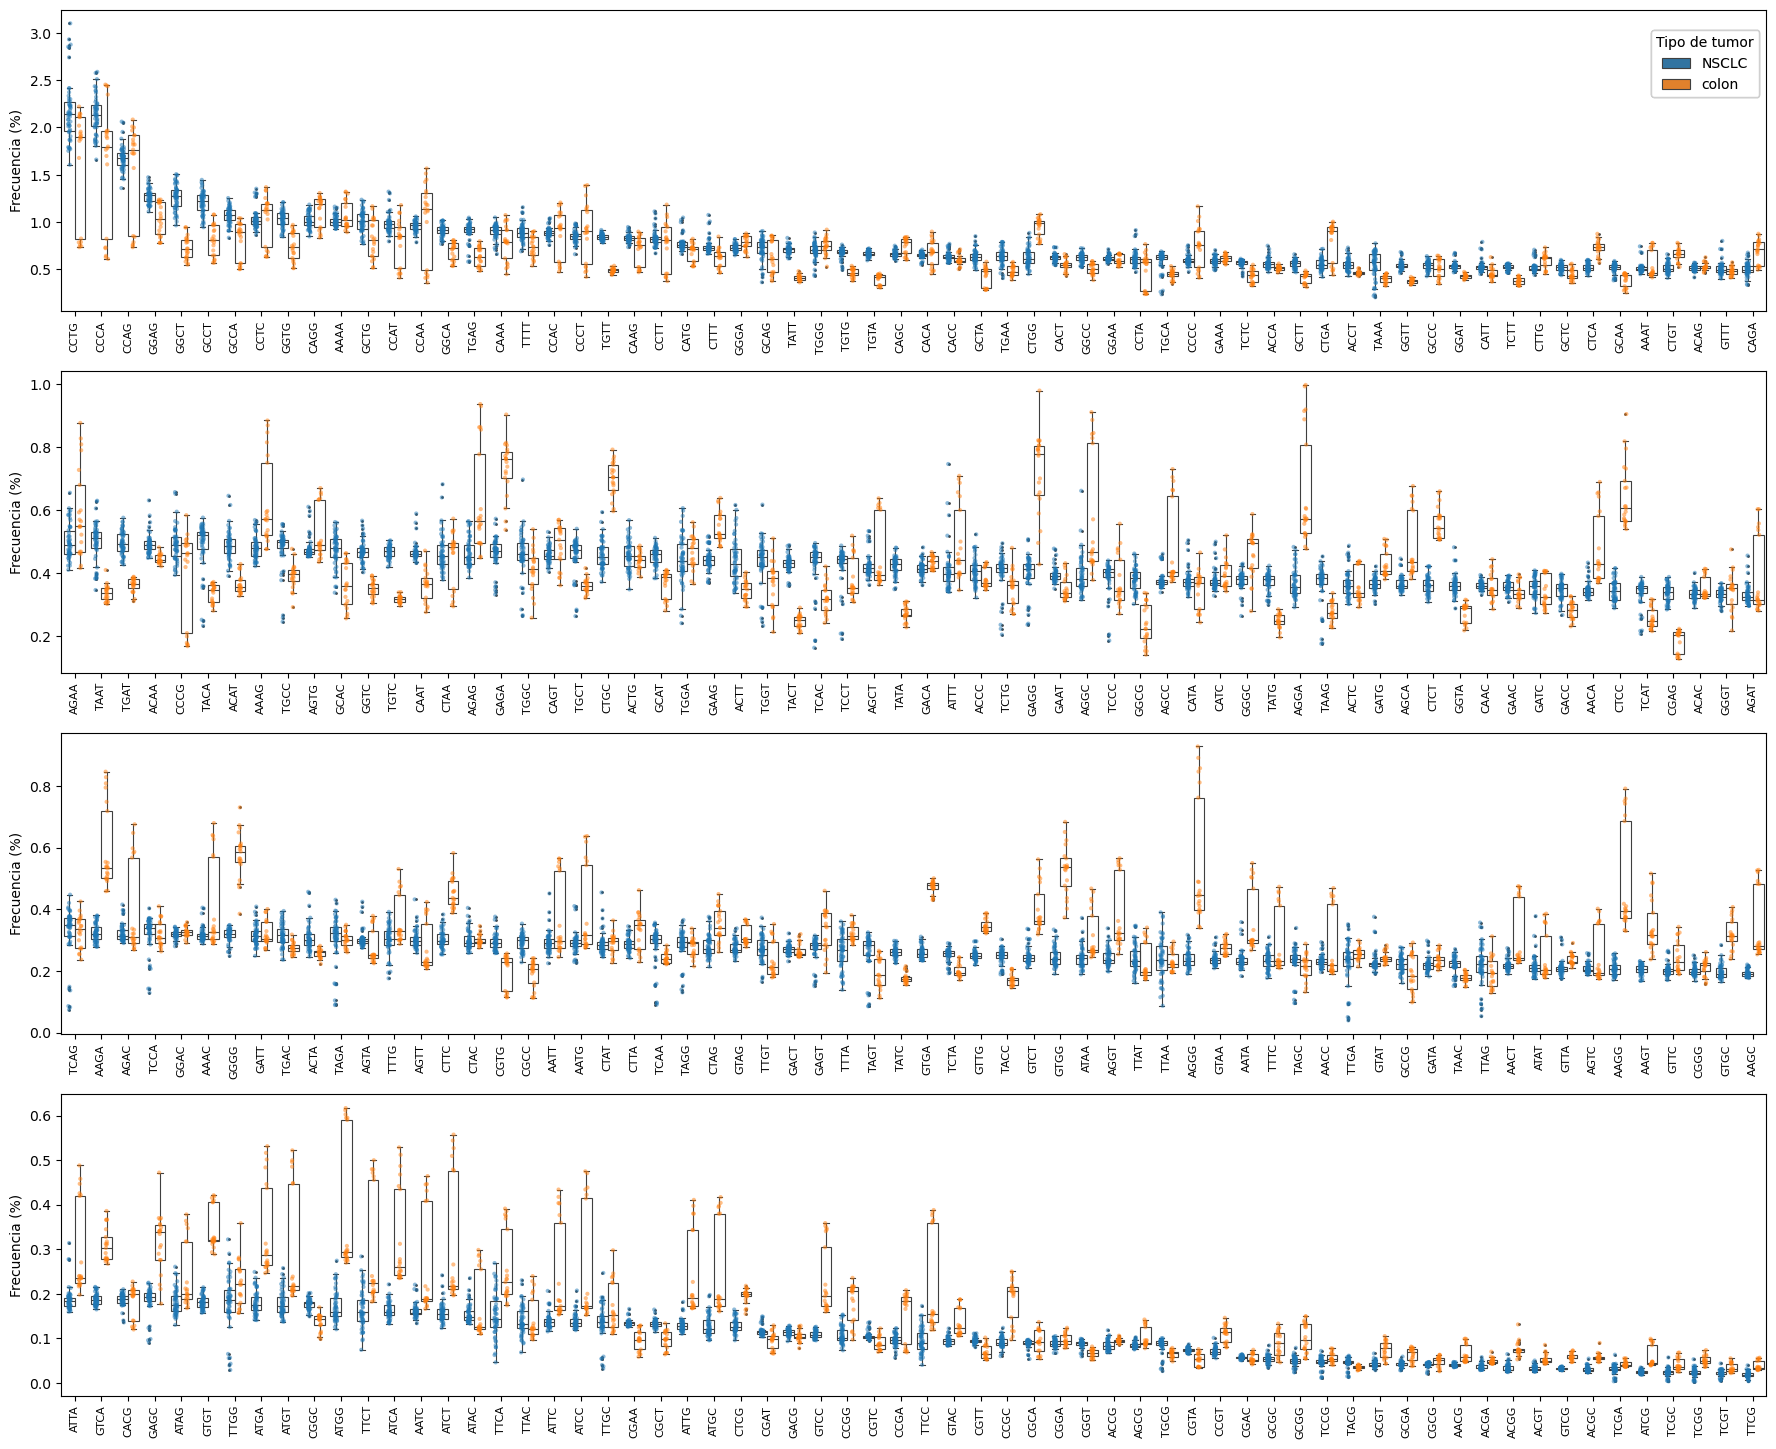

In [53]:
# boxplot motivos diferentes colon vs NSCLC
# porcentaje
df_endmot_all['percent'] = df_endmot_all['freq']*100

# ordenar decreciente frecuencia NSCLC
order = (df_endmot_all[df_endmot_all["cancer_type"]=="NSCLC"]
         .groupby("motif")["freq"]
         .mean()
         .sort_values(ascending=False)
         .index.tolist())

# Split into 4 chunks of 64 motifs each
chunks = [order[i:i+64] for i in range(0, len(order), 64)]

fig, axes = plt.subplots(4, 1, figsize=(22,18), sharey=False)

for ax, subset in zip(axes, chunks):
    df_sub = df_endmot_all[df_endmot_all["motif"].isin(subset)]

    sns.boxplot(data=df_sub,
                x="motif", 
                y="percent",
                hue="cancer_type",
                order=subset,
                ax=ax,
                boxprops=dict(facecolor="none"),
                fliersize=1,
                linewidth=0.8)

    sns.stripplot(data=df_sub,
                  x="motif", 
                  y="percent", 
                  hue="cancer_type",
                  order=subset, 
                  ax=ax,
                  dodge=True,            # aligns with boxplot groups
                  jitter=True,
                  alpha=0.5,             # transparent dots
                  size=3
                 )
    
    ax.legend_.remove()

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles[:2], 
               labels[:2], 
               title="Tipo de tumor",
               loc="right",
               bbox_to_anchor=(0.9,0.85)
              )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia (%)")

In [55]:
from scipy.stats import mannwhitneyu

results = []

for motif in df_endmot_all["motif"].unique():
    nsclc_vals = df_endmot_all[(df_endmot_all.motif == motif) & 
                               (df_endmot_all.cancer_type == "NSCLC")]["percent"]
    colon_vals = df_endmot_all[(df_endmot_all.motif == motif) & 
                               (df_endmot_all.cancer_type == "colon")]["percent"]

    mean_n = nsclc_vals.mean()
    mean_c = colon_vals.mean()
    
    # real fold change (ratio)
    foldchange = mean_n / mean_c if mean_c > 0 else np.nan
    
    # stats
    stat, p = mannwhitneyu(nsclc_vals, colon_vals, alternative='two-sided')
    
    results.append([motif, mean_n, mean_c, foldchange, 
                    p])

df_stats = pd.DataFrame(results, 
                        columns=["motif","mean_nsclc","mean_colon",
                                 "foldchange",
                                 "p_value"])

In [56]:
# corrijo p-value por test multiples
from statsmodels.stats.multitest import multipletests

df_stats["FDR"] = multipletests(df_stats["p_value"], method="fdr_bh")[1]

df_stats.head()

,motif,mean_nsclc,mean_colon,foldchange,p_value,FDR
0,AAAA,1.009157,1.068374,0.944574,4.536813e-01,4.645697e-01
1,AAAC,0.318038,0.403813,0.787588,8.386616e-02,9.499883e-02
2,AAAG,0.481322,0.622372,0.773367,6.293987e-08,1.389018e-07
3,AAAT,0.512828,0.538034,0.953151,2.458412e-02,3.100264e-02
4,AACA,0.346179,0.470800,0.735299,9.461825e-10,2.883604e-09


In [57]:
# elegir 6 motivos representativos (3 NSCLC>colon (FC>1) vs 3 NSCLC<colon (FC<1) maximizando las medias)
# stat. signif
print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['mean_nsclc', 'foldchange'], ascending=False).head(n=6))

print(df_stats[df_stats["FDR"] < 0.05].sort_values(by=['foldchange', 'mean_colon'], ascending=True).head(n=6))

    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR
94   CCTG    2.168198    1.643941    1.318903  1.969790e-04  3.151665e-04
84   CCCA    2.132021    1.623708    1.313057  3.419396e-04  5.305245e-04
162  GGAG    1.272798    1.029240    1.236639  2.469056e-08  5.798884e-08
167  GGCT    1.263953    0.726041    1.740883  2.315127e-11  1.743154e-10
151  GCCT    1.200943    0.809702    1.483191  2.261672e-10  8.514528e-10
148  GCCA    1.069381    0.814546    1.312855  1.245062e-08  3.035581e-08
    motif  mean_nsclc  mean_colon  foldchange       p_value           FDR
54   ATCG    0.024132    0.057446    0.420078  2.315127e-11  1.743154e-10
10   AAGG    0.207711    0.481995    0.430939  2.315127e-11  1.743154e-10
42   AGGG    0.239673    0.542513    0.441782  2.315127e-11  1.743154e-10
26   ACGG    0.033625    0.075695    0.444220  3.457745e-11  2.011779e-10
218  TCGG    0.022773    0.050580    0.450239  1.219943e-10  5.119759e-10
58   ATGG    0.171198    0.377035    0

In [59]:
# motivos seleccionados
rep_motifs = ['CCTG', 'CCCA', 'GGAG',
              'AAGG', 'AGGG', 'ATGG'
             ]

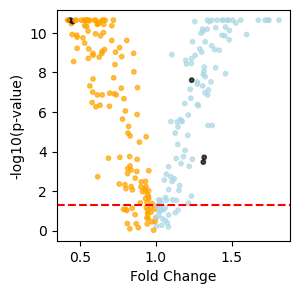

In [61]:
import numpy as np

# asignar colores por filas 
# nsclc azul (FC>1)
df_stats.loc[df_stats['foldchange'] > 1, 'color_col'] = 'lightblue'

# colon naranja (FC<1)
df_stats.loc[df_stats['foldchange'] < 1, 'color_col'] = 'orange'

df_stats.loc[df_stats['motif'].isin(rep_motifs), 'color_col'] = 'black'

# convertir p-value a -log10(p-value) para volcano
df_stats['neg_log10_p'] = -np.log10(df_stats['p_value'])

plt.figure(figsize=(3, 3))
plt.scatter(df_stats['foldchange'], 
            df_stats['neg_log10_p'], 
            s=10,
            c=df_stats['color_col'],
            alpha=0.7)

# linea en signif
plt.axhline(
    y=-np.log10(0.05),
    linestyle='--',
    c = "red"
)

plt.xlabel("Fold Change")
plt.ylabel("-log10(p-value)")

plt.show()

/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_9769/864542095.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
/var/folders/3n/cmq87plj5zx43b8bbf_fdhth0000gp/T/ipykernel_9769/864542095.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)


[Text(0, 0, 'CCTG'),
 Text(1, 0, 'CCCA'),
 Text(2, 0, 'GGAG'),
 Text(3, 0, 'AAGG'),
 Text(4, 0, 'AGGG'),
 Text(5, 0, 'ATGG')]

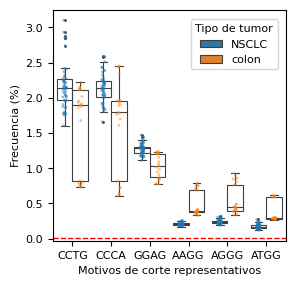

In [539]:
fig, ax = plt.subplots(figsize=(3, 3))

sns.boxplot(data=df_endmot_all[df_endmot_all["motif"].isin(rep_motifs)],
            ax = ax,
            x="motif",
            y="percent",
            hue="cancer_type",
            order=rep_motifs,
            boxprops=dict(facecolor="none"),
            fliersize=1,
            linewidth=0.8)

sns.stripplot(data=df_endmot_all[df_endmot_all["motif"].isin(rep_motifs)],
              ax = ax,
              x="motif",
              y="percent", 
              hue="cancer_type",
              order=rep_motifs,
              dodge=True,
              jitter=True,
              alpha=0.5,
              size=2) 

ax.legend_.remove()

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2],
          labels[:2],
          title="Tipo de tumor",
          loc="right",
          bbox_to_anchor=(0.99,0.85),
          title_fontsize=8,
          fontsize=8
          )

ax.axhline(y=0.0039, color='r', linestyle='--', linewidth = 1)

ax.set_ylabel("Frecuencia (%)", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

ax.set_xlabel("Motivos de corte representativos", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

### MDS

* Al tener ya los archivos .tsv para los motivos de corte de colon, no aplique el siguiente codigo en Python descrito en la documentacion de FinaleToolkit https://github.com/epifluidlab/FinaleToolkit/wiki/3c3d

* Para calcular el MDS, utilizo la formula de la entropia de Shannon normalizada que emplea Finaletoolkit descrita en https://aacrjournals.org/cancerdiscovery/article/10/5/664/2457/Plasma-DNA-End-Motif-Profiling-as-a-Fragmentomic

In [657]:
# algun archivo con freq=0?
# NSCLC - no 0
path = os.path.join(results_endmot, "*.filtered.k4.tsv")  # adjust to your directory

# colon - no o
#path = "../UOC/TFM/00_datos/fragmentomics_colon_lesende/*.tsv"

files_with_zero = []

for f in glob.glob(path):
    df = pd.read_csv(f, sep="\t", header=None, names=["motif","freq"])
    
    # ver si algun motivo - freq=0
    if (df["freq"] == 0).any():
        files_with_zero.append(os.path.basename(f))

# imprimir si hay 0s o si no
if files_with_zero:
    print("Files containing frequency = 0:")
    for file in files_with_zero:
        print(" -", file)
else:
    print("No files contain frequency = 0")

No files contain frequency = 0


In [704]:
# funcion para calcular MDS en NSCLS y colon
import re
import math

path_endmot_nsclc = os.path.join(results_endmot, "*.filtered.k4.tsv") 
path_endmot_colon = "../UOC/TFM/00_datos/fragmentomics_colon_lesende/*.tsv"
# hay que especificar los archivos de 4-mer (histo-fraglen y 2-2mer)
# if not os.path.basename(f).startswith(("histo", "2"))
k = 4
max_entropy = math.log(4**k)

# lista para guardar calculos
records = []

def compute_MDS(file, cancer_type):
    samplename = re.sub(r'\.(bam\.tsv|filtered\.k4\.tsv)$', '', os.path.basename(file))
    df = pd.read_csv(file, sep="\t", header=None, names=["motif","freq"])

    p = df["freq"].values
    h = -np.sum(p * np.log(p)) # entropia
    mds_norm = h / max_entropy

    # guardar resultados en lista
    records.append([samplename, mds_norm, cancer_type])

In [705]:
# calcular MDS aplicando la formula a cada muestra
for f in glob.glob(path_endmot_nsclc):
    compute_MDS(f, "NSCLC")

for f in glob.glob(path_endmot_colon):
    samplename = os.path.basename(f)
    # ignorar tsv para el histograma o 2-mer endmotifs
    if samplename.startswith(("histo", "2")):
        continue
    compute_MDS(f, "colon")

# transformar lista en df
df_mds = pd.DataFrame(records, columns=["sample", "mds", "cancer_type"])

# excluir muestras de referencia
df_mds = df_mds[~df_mds["sample"].isin(ctrl_samples)]
print(df_mds)

              sample       mds cancer_type
0      L-25000063_S1  0.955832       NSCLC
1            2-CH_S1  0.941417       NSCLC
2      L-25000090_S7  0.954018       NSCLC
3      L-25000066_S7  0.950604       NSCLC
4      L-25000057_S2  0.950554       NSCLC
..               ...       ...         ...
72        L4102cf(1)  0.957343       colon
73         SeraseqWT  0.968488       colon
74  Cas4814cf-18colh  0.949667       colon
75       Seraseq1(1)  0.970913       colon
76  Cas4826cf-16colh  0.951889       colon

[75 rows x 3 columns]


NameError: name 'df_mds' is not defined

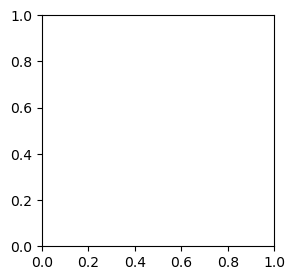

In [63]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, NullLocator

# box MDS
fig, ax = plt.subplots(figsize=(3, 3))

# box
sns.boxplot(data=df_mds,
            ax = ax,
            x="cancer_type",
            y="mds",
            hue="cancer_type",
            boxprops=dict(facecolor="none"),
            fliersize=1,
            linewidth=0.8)

# dots
sns.stripplot(data=df_mds,
              ax = ax,
              x="cancer_type",
              y="mds", 
              hue="cancer_type",
              jitter=True,
              alpha=1,
              size=3) 

ax.yaxis.set_major_locator(MultipleLocator(0.01)) # 2 decimales
ax.set_ylabel("MDS", fontsize=8)
ax.set_xlabel("Tipo de cáncer", fontsize=8)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)

In [730]:
df_mds.sort_values(by="mds", ascending=True).head()

,sample,mds,cancer_type
27,6-CH_S3,0.936876,NSCLC
13,9-CH_S4,0.940115,NSCLC
5,10-CH_S5,0.940335,NSCLC
1,2-CH_S1,0.941417,NSCLC
48,4-CH_S2,0.942043,NSCLC


In [62]:
df_mds["cancer_type"].value_counts()

NameError: name 'df_mds' is not defined

In [725]:
mds_colon = df_mds.loc[df_mds["cancer_type"] == "colon", "mds"]
mds_nsclc = df_mds.loc[df_mds["cancer_type"] == "NSCLC", "mds"]

u_stat, p_value = mannwhitneyu(
    mds_colon,
    mds_nsclc,
    alternative="two-sided"
)

print(f"Mann–Whitney estadístico = {u_stat:.2f}")
print(f"p-valor = {p_value:.3e}")

Mann–Whitney estadístico = 902.00
p-valor = 7.912e-05
